In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from modules import CHIP,ADC,WIRE_RESISTANCE,COMPENSATION
import numpy as np
import matplotlib.pyplot as plt

from util import *

In [57]:
v1=np.load("../chip_data/chip6_/pcb_203/v_1.npy")
v32=np.load("../chip_data/chip6_/pcb_203/v_32.npy")

In [58]:
compensation = COMPENSATION()
compensation.initop("../chip_data/chip6_/pcb_203/")
chip = CHIP(None,0,IsNew32=True,init=False)
adc = ADC(None,None,False)
adc.gain = 1

In [66]:
# 逐点读真实电导
r1 = adc.voltage_to_resistance(v1,0.1)*1e3
r_real_1 = r1 - compensation.r_w_col - compensation.r_w_row - compensation.row_r_out
c_real_1 = 1/r_real_1*1e6


r32 = adc.voltage_to_resistance(v32,0.1)*1e3
r_real_32 = r32 - compensation.r_w_col - compensation.r_w_row - compensation.row_r_out
c_real_32 = 1/r_real_32*1e6

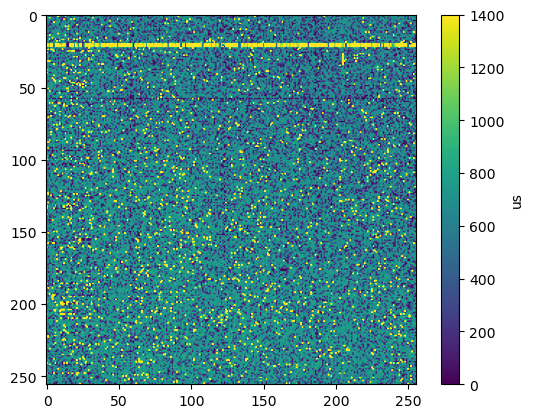

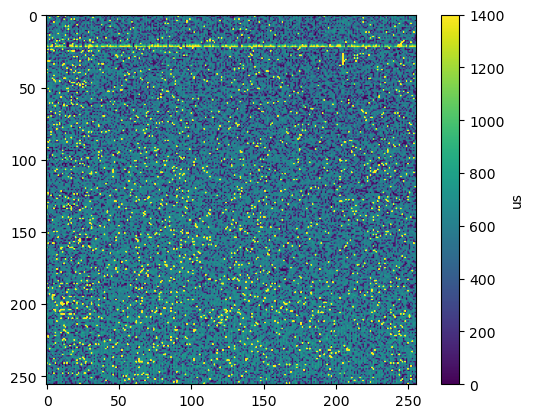

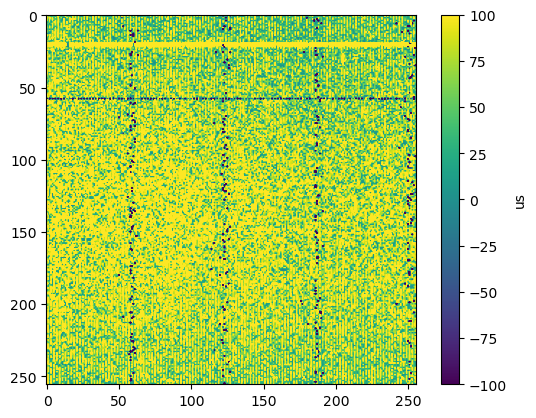

In [67]:
plot_cond(c_real_1)
plot_cond(c_real_32)
plot_cond(c_real_1-c_real_32,vmin=-100,vmax=100)

In [68]:
crossbar = np.ones((256,256))
operator_batch = chip.crossbar_split_to_batch4(crossbar,None,None,False,1)
i = adc.voltage_to_current(v32)
i[i<1e-18] = 1e-18
r_real_32 = np.zeros_like(i)

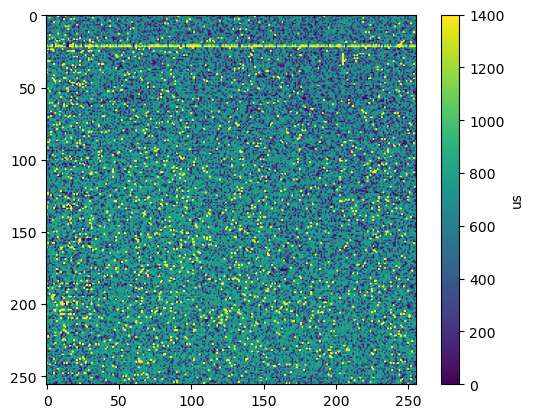

In [69]:
# rows,cols = operator_batch[i]
r_wire = compensation.r_wire
start_v = 0.1
for rows,cols in operator_batch:
    col = cols[0]
    rows=sorted(rows,reverse=(col%2==0))
    i_sum = np.sum(i[rows,col])

    min_row_on,max_row_on = np.min(rows),np.max(rows)

    r_w = r_wire*(255-max_row_on) if col%2==0 else r_wire*min_row_on
    
    v = start_v - r_w * i_sum
    last_row = rows[0]
    # 减去线阻分压
    for row in rows:
        v -= r_wire*(abs(last_row-row))*i_sum
        r_real_32[row,col] = v/i[row,col]
        i_sum -= i[row,col]
        last_row = row

r_real_32 = r_real_32 - compensation.r_w_row - compensation.row_r_out
c_real_32 = 1/r_real_32*1e6
plot_cond(c_real_32)

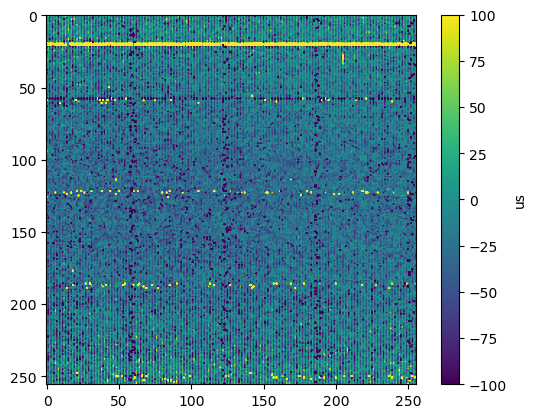

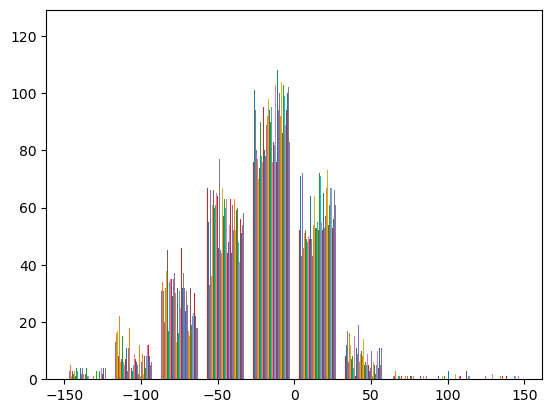

In [70]:
plot_cond(c_real_1-c_real_32,vmin=-100,vmax=100)
plt.hist(c_real_1-c_real_32,range=(-150,150))
plt.show()
# c_real_1[np.abs(c_real_1-c_real_32)<=100] =0 
# plot_cond(c_real_1)


In [ ]:
wrm=WIRE_RESISTANCE()

In [ ]:
r_device=100e3
for r_device in [1e3,5e3,10e3,50e3,100e3,500e3]:
    r_wire=0.12
    r_out=18
    row_num=256
    expected,expected_with_r_out,actual,actual_with_r_out = wrm.get_result(r_device=r_device,r_wire=r_wire,r_out=r_out,row_num=row_num)
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.plot(expected,label="expected")
    plt.plot(expected_with_r_out,label="expected+r_out")
    plt.plot(actual,label="actual only_r_wire")
    plt.plot(actual_with_r_out,label="actual r_wire + r_out")
    plt.xlabel("row num")
    plt.ylabel("S")
    plt.title(f"r_device={r_device/1e3}kΩ, r_wire={r_wire}Ω\nr_wire/r_device={r_wire/r_device*1e6:.1f}*1e-6, r_out={r_out}Ω")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(expected/expected,label="expected/expected")
    plt.plot(expected_with_r_out/expected,label="expected + r_out/expected")
    plt.plot(actual/expected,label="actual only_r_wire/expected")
    plt.plot(actual_with_r_out/expected,label="actual r_wire + r_out/expected")
    plt.plot(np.ones(256)*0.98,label="0.98")
    plt.xlabel("row num")
    plt.ylabel("percent")
    plt.title(f"r_device={r_device/1e3}kΩ, r_wire={r_wire}Ω\nr_wire/r_device={r_wire/r_device*1e6:.1f}*1e-6, r_out={r_out}Ω")
    plt.legend()
    
# plt.tight_layout()
    plt.show()

In [ ]:
r_device=100e3
for r_device in [1e3,5e3,10e3,50e3,100e3,500e3]:
    r_device = np.ones(256)*r_device
    r_device[25]=0.2e3
    r_device[50]=0.2e3
    r_wire=0.12
    r_out=18
    row_num=256
    expected,expected_with_r_out,actual,actual_with_r_out = wrm.get_result2(r_device=r_device,r_wire=r_wire,r_out=r_out,row_num=row_num)
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.plot(expected,label="expected")
    plt.plot(expected_with_r_out,label="expected+r_out")
    plt.plot(actual,label="actual only_r_wire")
    plt.plot(actual_with_r_out,label="actual r_wire + r_out")
    plt.xlabel("row num")
    plt.ylabel("S")
    plt.title(f"r_device={r_device[0]/1e3}kΩ, r_wire={r_wire}Ω\nr_wire/r_device={r_wire/r_device[0]*1e6:.1f}*1e-6, r_out={r_out}Ω")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(expected/expected,label="expected/expected")
    plt.plot(expected_with_r_out/expected,label="expected + r_out/expected")
    plt.plot(actual/expected,label="actual only_r_wire/expected")
    plt.plot(actual_with_r_out/expected,label="actual r_wire + r_out/expected")
    plt.plot(np.ones(256)*0.98,label="0.98")
    plt.xlabel("row num")
    plt.ylabel("percent")
    plt.title(f"r_device={r_device[0]/1e3}kΩ, r_wire={r_wire}Ω\nr_wire/r_device={r_wire/r_device[0]*1e6:.1f}*1e-6, r_out={r_out}Ω")
    plt.legend()
    
# plt.tight_layout()
    plt.show()